In [483]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import PowerTransformer,FunctionTransformer
from sklearn.compose import ColumnTransformer

In [484]:
df=sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [485]:
df['cut'].nunique()

5

In [486]:
df.shape

(53940, 10)

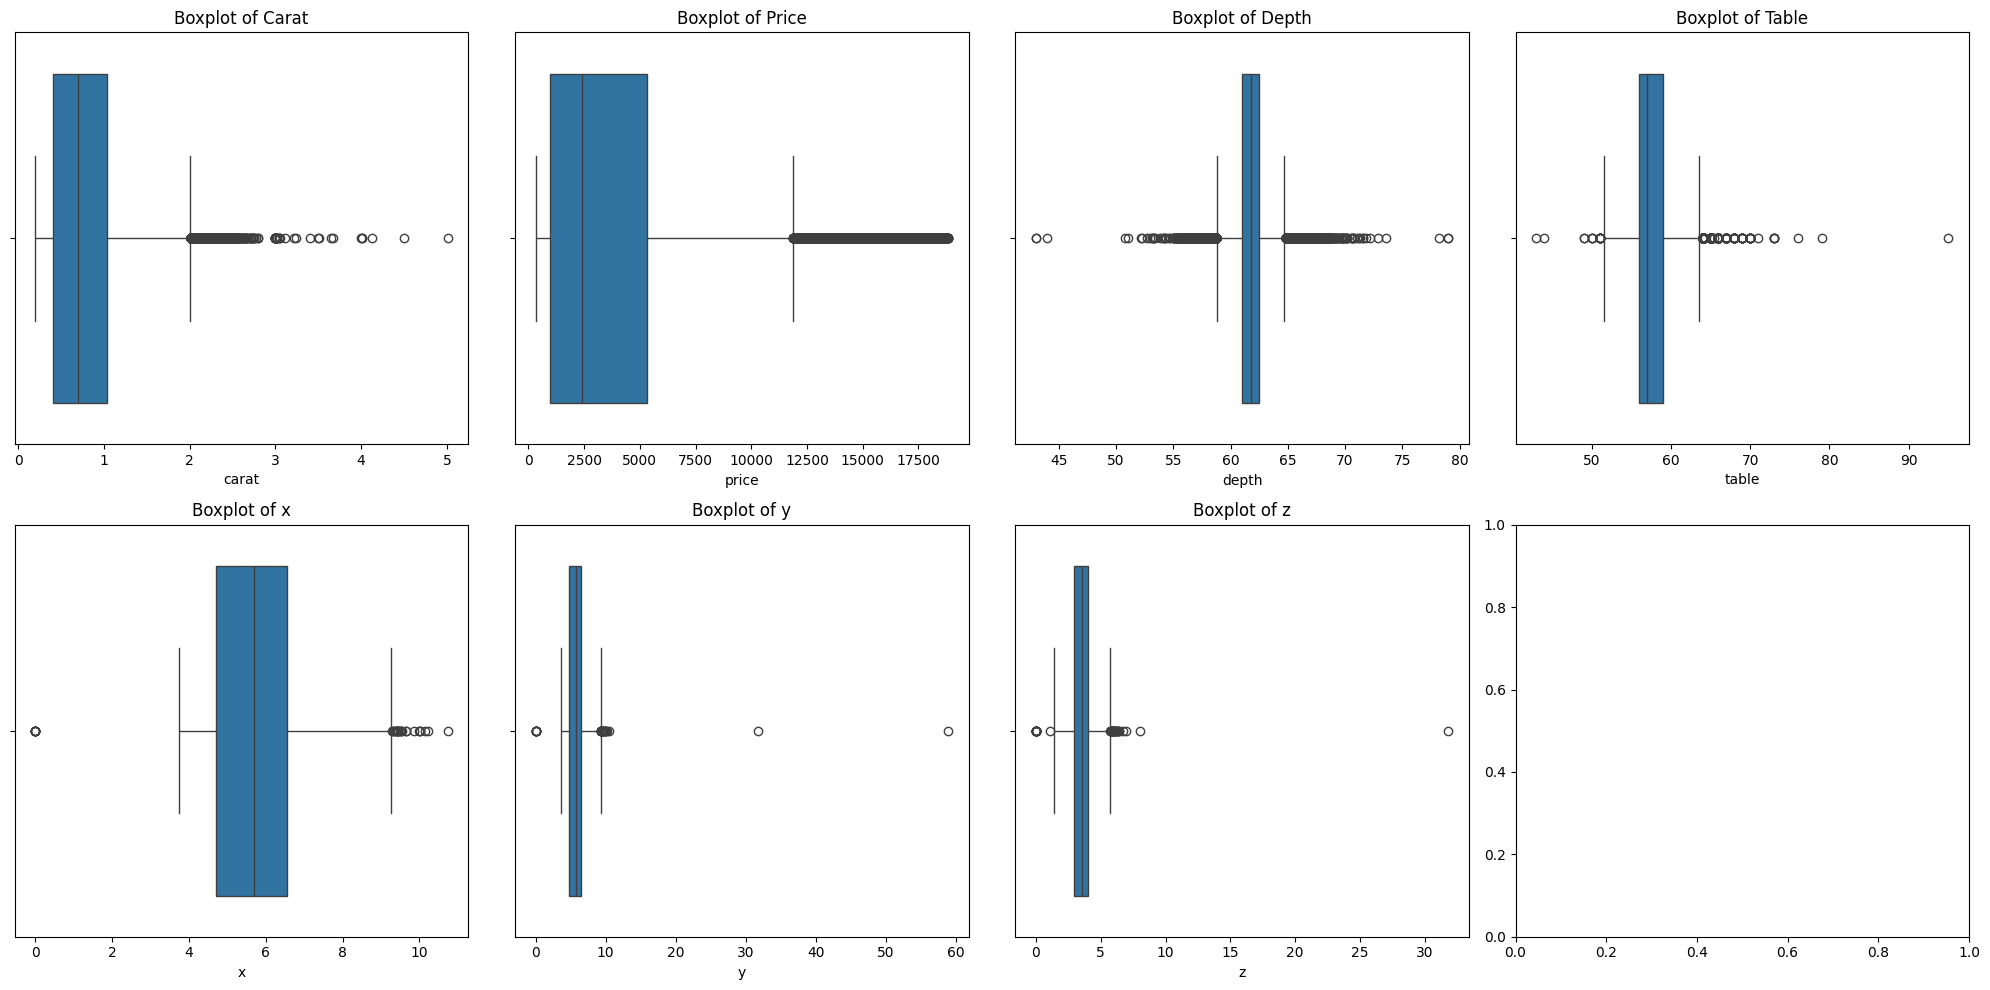

In [487]:
#outliers before the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [488]:
#conditon to remove
df=df[(df['x']>0)|(df['y']>0)|(df['z']>0)]

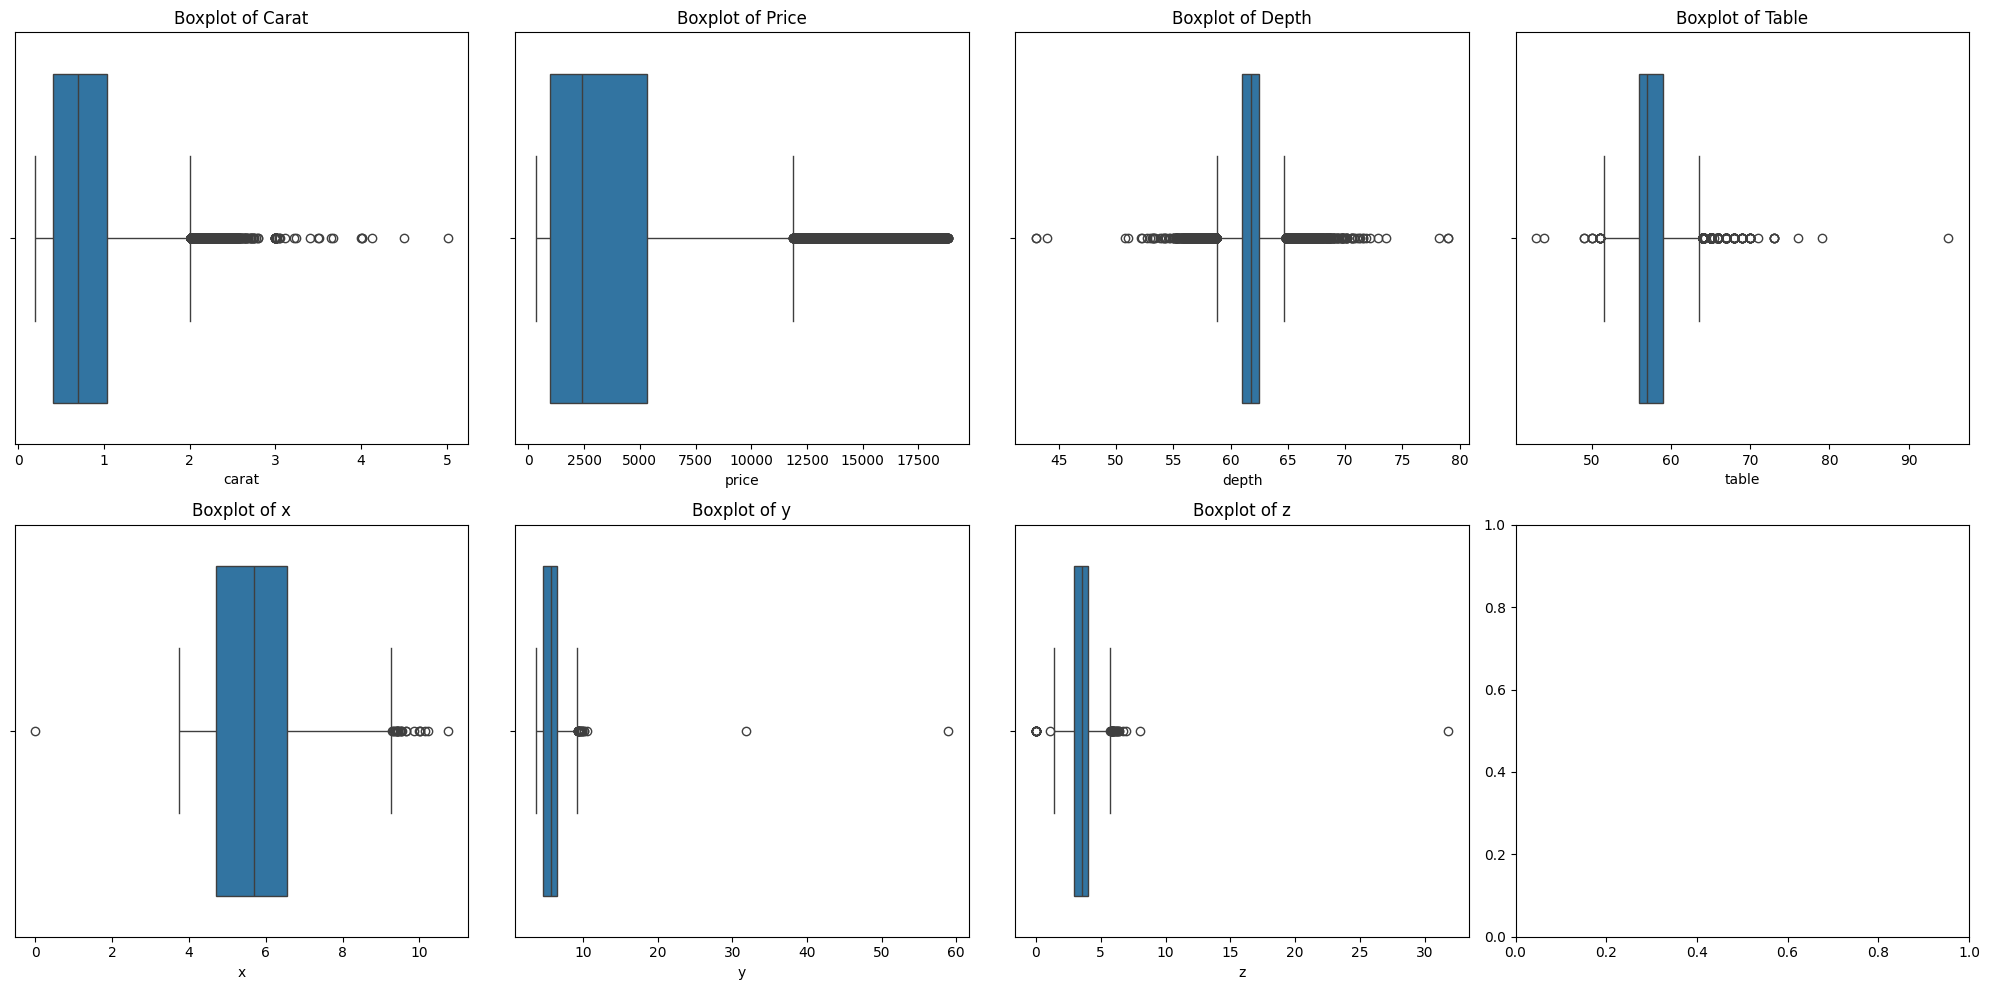

In [489]:
#outliers after the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [490]:
df.shape

(53933, 10)

In [491]:
# 3. Ab Statistical Outliers ko hatayein (IQR Method)
numerical_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Condition banao
    condition = (df[col] >= lower_bound) & (df[col] <= upper_bound)

    df = df[condition]

print(f"Size after removing statistical outliers: {df.shape}")



Size after removing statistical outliers: (46530, 10)


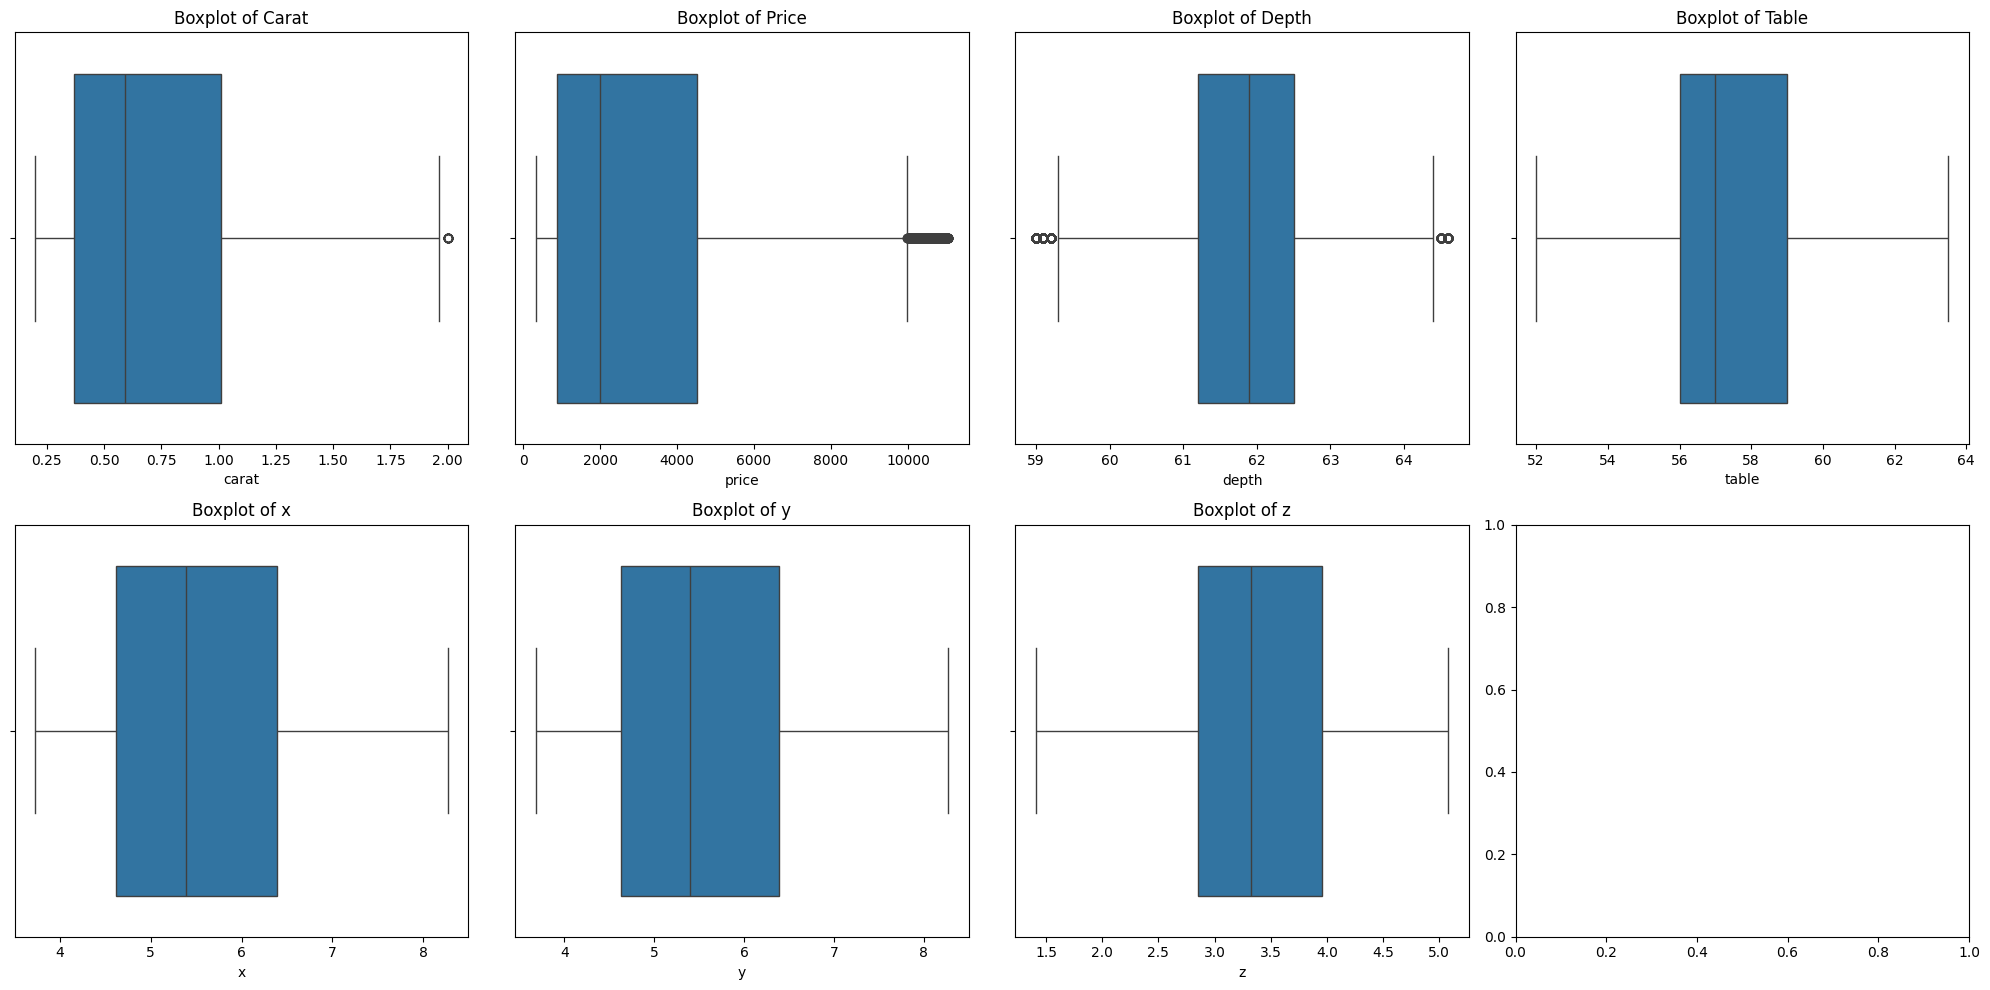

In [492]:
#outliers after the condition implementation 

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.boxplot(x=df['carat'], ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.boxplot(x=df['price'], ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.boxplot(x=df['depth'], ax=axs[0, 2])
axs[0, 2].set_title('Boxplot of Depth')

# --- Fill the rest of the plots ---
sns.boxplot(x=df['table'], ax=axs[0, 3])
axs[0, 3].set_title('Boxplot of Table')

sns.boxplot(x=df['x'], ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of x')

sns.boxplot(x=df['y'], ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of y')

sns.boxplot(x=df['z'], ax=axs[1, 2])
axs[1, 2].set_title('Boxplot of z')



plt.tight_layout()
plt.show()


In [493]:
le=LabelEncoder()
df['cut']=le.fit_transform(df['cut'])

In [494]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,4,J,VVS2,62.8,57.0,336,3.94,3.96,2.48


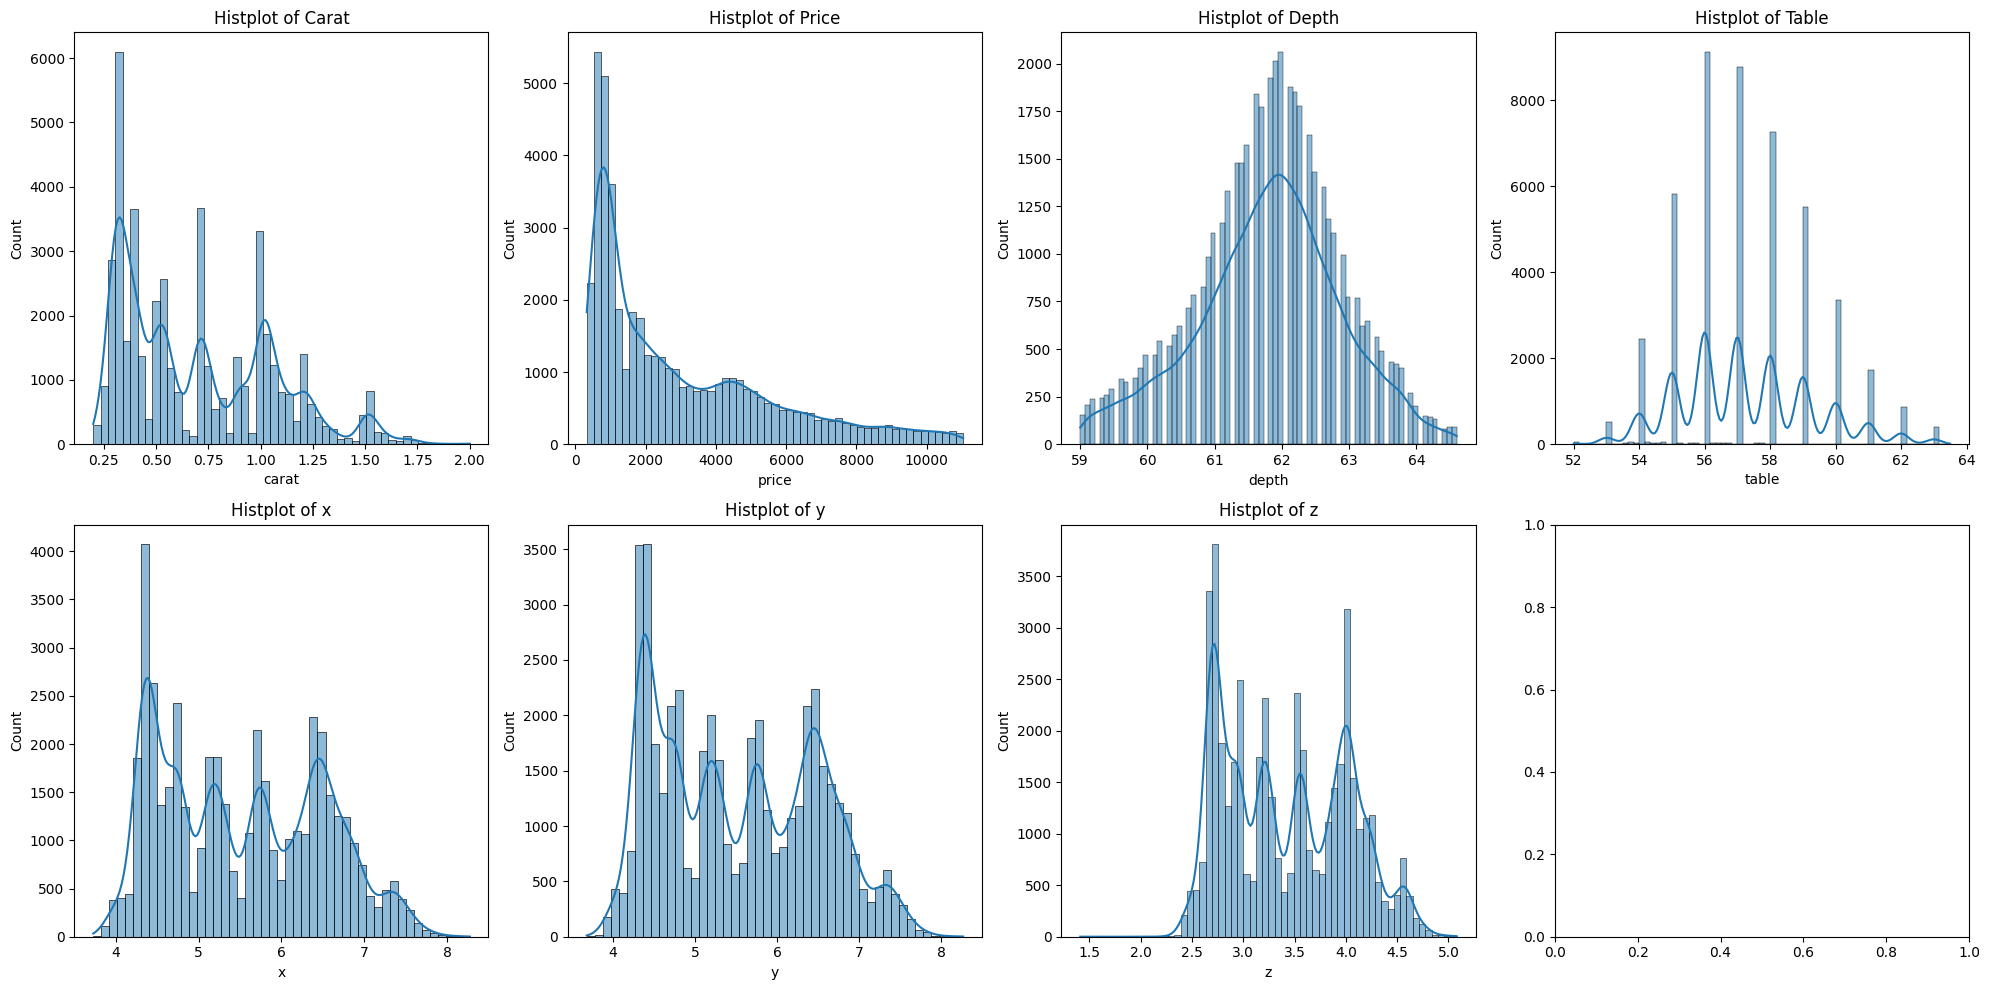

In [511]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Plot 1: Carat (Top-Left) ---
sns.histplot(data=df['carat'],kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Histplot of Carat')

# --- Plot 2: Price (Top-Row, 2nd plot) ---
sns.histplot(data=df['price'],kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Histplot of Price')

# --- Plot 3: Depth (Top-Row, 3rd plot) ---
sns.histplot(data=df['depth'],kde=True, ax=axs[0, 2])
axs[0, 2].set_title('Histplot of Depth')

# --- Fill the rest of the plots ---
sns.histplot(data=df['table'],kde=True, ax=axs[0, 3])
axs[0, 3].set_title('Histplot of Table')

sns.histplot(data=df['x'], kde=True,ax=axs[1, 0])
axs[1, 0].set_title('Histplot of x')

sns.histplot(data=df['y'], kde=True,ax=axs[1, 1])
axs[1, 1].set_title('Histplot of y')

sns.histplot(data=df['z'], kde=True,ax=axs[1, 2])
axs[1, 2].set_title('Histplot of z')



plt.tight_layout()
plt.show()


In [496]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,4,J,VVS2,62.8,57.0,336,3.94,3.96,2.48


In [497]:
X = df.drop(columns=['cut'],axis=1)
y = df['cut']

In [498]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [499]:
X_train.shape

(37224, 9)

In [500]:
X_test.shape

(9306, 9)

In [501]:
transformer=ColumnTransformer(transformers=[
    ('num',PowerTransformer(method='yeo-johnson'),['carat', 'depth', 'table', 'price', 'x', 'y', 'z']),
    ('cat',OneHotEncoder(sparse_output=False,drop='first'),['color','clarity'])
],remainder='passthrough')

In [506]:
X_train_trans=transformer.fit_transform(X_train)

In [507]:
X_test_trans=transformer.transform(X_test)

In [509]:
pd.DataFrame(X_train_trans).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,-0.829410,-0.131380,0.445202,-1.234693,-0.848798,-0.798863,-0.827747,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.025695,0.243077,-1.158000,0.186825,0.074412,0.088185,0.103777,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.235027,-1.199324,-0.048561,0.264181,0.387183,0.362467,0.252107,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-1.308091,0.530166,-1.781963,-1.587175,-1.346153,-1.319599,-1.264141,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.171985,0.148576,-0.048561,0.906786,1.170261,1.112614,1.155545,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


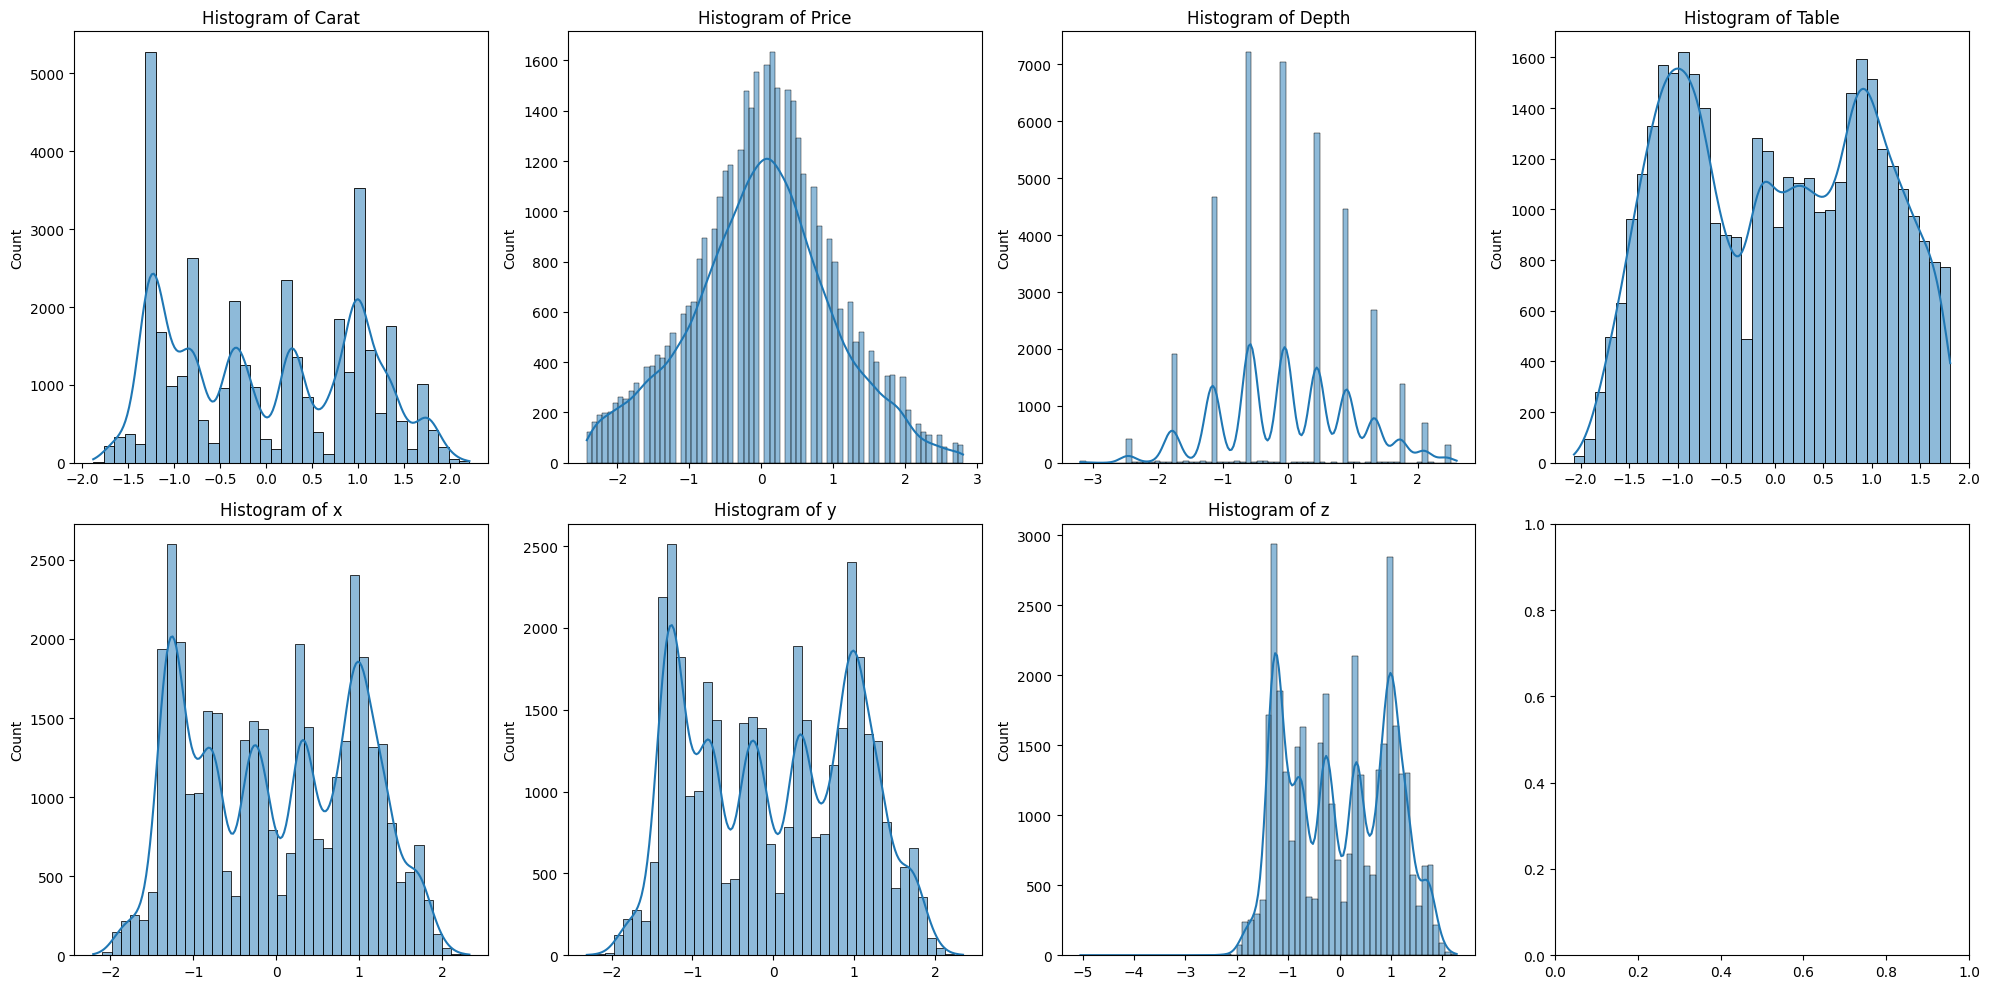

In [510]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

sns.histplot(X_train_trans[:, 0], kde=True, ax=axs[0, 0])
axs[0, 0].set_title('Histogram of Carat')

sns.histplot(X_train_trans[:, 1], kde=True, ax=axs[0, 1])
axs[0, 1].set_title('Histogram of Price')

sns.histplot(X_train_trans[:, 2], kde=True, ax=axs[0, 2])
axs[0, 2].set_title('Histogram of Depth')

sns.histplot(X_train_trans[:, 3], kde=True, ax=axs[0, 3])
axs[0, 3].set_title('Histogram of Table')

sns.histplot(X_train_trans[:, 4], kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Histogram of x')

sns.histplot(X_train_trans[:, 5], kde=True, ax=axs[1, 1])
axs[1, 1].set_title('Histogram of y')

sns.histplot(X_train_trans[:, 6], kde=True, ax=axs[1, 2])
axs[1, 2].set_title('Histogram of z')

plt.tight_layout()
plt.show()


In [ ]:
for cols in ['color','clarity']:
    le=LabelEncoder()
    dia[cols]=le.fit_transform(dia[cols])

np.random.seed(43)
ran=np.random.choice(dia.index, size=int(0.91*len(dia)), replace=False)
print(dia.info())

scaler=MinMaxScaler()
columns_for_norm=['depth','table','price','x','y','z']
dia_norm=pd.DataFrame(scaler.fit_transform(dia[columns_for_norm]), columns=columns_for_norm)


#Original Data Summ
print("\nOriginal Data Summ\n")
print(dia.describe())
print("\nNormalised Data Summ\n")
print(dia_norm.describe())


#columns_for_training=['depth','x','y','z']
dia_train=dia_norm.loc[ran,:]
dia_test=dia_norm.drop(ran)
dia_target_cat=dia.iloc[ran, 1]
dia_test_cat=dia.drop(ran)['cut']

#KNN
knn=KNeighborsClassifier(n_neighbors=32,metric='manhattan')
knn.fit(dia_train, dia_target_cat)
pr=knn.predict(dia_test)

#Confusion Matrix
matrix1=confusion_matrix(dia_test_cat, pr)
print("\nConfusion Matrix\n",matrix1)


#Accuracy Score
ac1=accuracy_score(dia_test_cat, pr)*100
print("\nAccuracy: {:.2f}".format(ac1))


NameError: name 'dia' is not defined